# Notebook 1: Data Audit & Cleaning
**Dataset:** RBA (Risk-Based Authentication) — `rba-dataset.csv` (~8.5 GB)  
**Strategy:** Sample 1 million rows for efficient processing  
**Target columns:** `Is Attack IP`, `Is Account Takeover`, `Login Successful`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATA_PATH = r'C:\Users\ruchi\Downloads\rba-dataset.csv\rba-dataset.csv'
SAMPLE_SIZE = 1_000_000
RANDOM_STATE = 42

print('Libraries loaded.')

Libraries loaded.


## 1. Sample 1M Rows from the Full Dataset

In [2]:
# Count total rows efficiently (without loading full file)
print('Counting total rows (this may take a minute for 8.5 GB)...')
total_rows = sum(1 for _ in open(DATA_PATH, encoding='utf-8')) - 1  # subtract header
print(f'Total rows in dataset: {total_rows:,}')

Counting total rows (this may take a minute for 8.5 GB)...
Total rows in dataset: 31,269,264


In [3]:
# Reservoir/skip-row sampling: choose SAMPLE_SIZE rows at random
import random
random.seed(RANDOM_STATE)

skip_rows = sorted(random.sample(range(1, total_rows + 1),
                                 total_rows - SAMPLE_SIZE))

print(f'Loading {SAMPLE_SIZE:,} sampled rows...')
df = pd.read_csv(DATA_PATH, skiprows=skip_rows)
print(f'Sample loaded. Shape: {df.shape}')
df.head(3)

Loading 1,000,000 sampled rows...
Sample loaded. Shape: (1000000, 16)


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,150,2020-02-03 12:46:25.828,-4324475583306591935,NaN,37.191.162.246,NO,Oslo County,Oslo,57963,Mozilla/5.0 (Android 6.0.99; Tablet; https://github.com...,Chrome Mobile WebView 85.0.4183,Android 6.0.99,mobile,False,False,False
1,192,2020-02-03 12:46:52.905,-4324475583306591935,NaN,94.198.241.134,CZ,Hlavni mesto Praha,Prague,62160,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 like Mac OS X...,Chrome Mobile WebView 85.0.4183,iOS 11.2.6,mobile,False,False,False
2,196,2020-02-03 12:46:55.455,9187119392009558735,NaN,10.0.183.79,RO,Arges,Curtea de Argeş,500372,Mozilla/5.0 (X11; CrOS armv7l 12105.100.0) AppleWebKit/...,Chrome 69.0.3497.17.19,Chrome OS 12105.100.0,desktop,True,False,False


## 2. Basic Data Audit

In [4]:
print('=== SCHEMA ===')
df.info()
print()
print('=== DTYPES ===')
print(df.dtypes)

=== SCHEMA ===
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 16 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   index                     1000000 non-null  int64  
 1   Login Timestamp           1000000 non-null  str    
 2   User ID                   1000000 non-null  int64  
 3   Round-Trip Time [ms]      40563 non-null    float64
 4   IP Address                1000000 non-null  str    
 5   Country                   1000000 non-null  str    
 6   Region                    998451 non-null   str    
 7   City                      999736 non-null   str    
 8   ASN                       1000000 non-null  int64  
 9   User Agent String         1000000 non-null  str    
 10  Browser Name and Version  1000000 non-null  str    
 11  OS Name and Version       1000000 non-null  str    
 12  Device Type               999938 non-null   str    
 13  Login Successful        

In [5]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df.to_string())

=== MISSING VALUES ===
                      Missing Count  Missing %
Round-Trip Time [ms]         959437      95.94
Region                         1549       0.15
City                            264       0.03
Device Type                      62       0.01


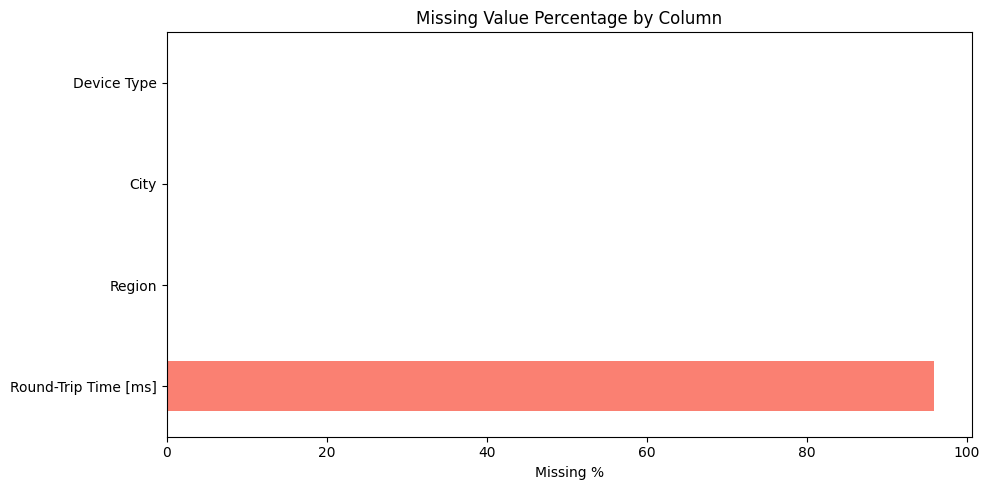

In [6]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='salmon')
ax.set_title('Missing Value Percentage by Column')
ax.set_xlabel('Missing %')
plt.tight_layout()
plt.show()

In [7]:
print('=== DUPLICATE ROWS ===')
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.2f}%)')

=== DUPLICATE ROWS ===
Duplicate rows: 0 (0.00%)


## 3. Target Variable Analysis

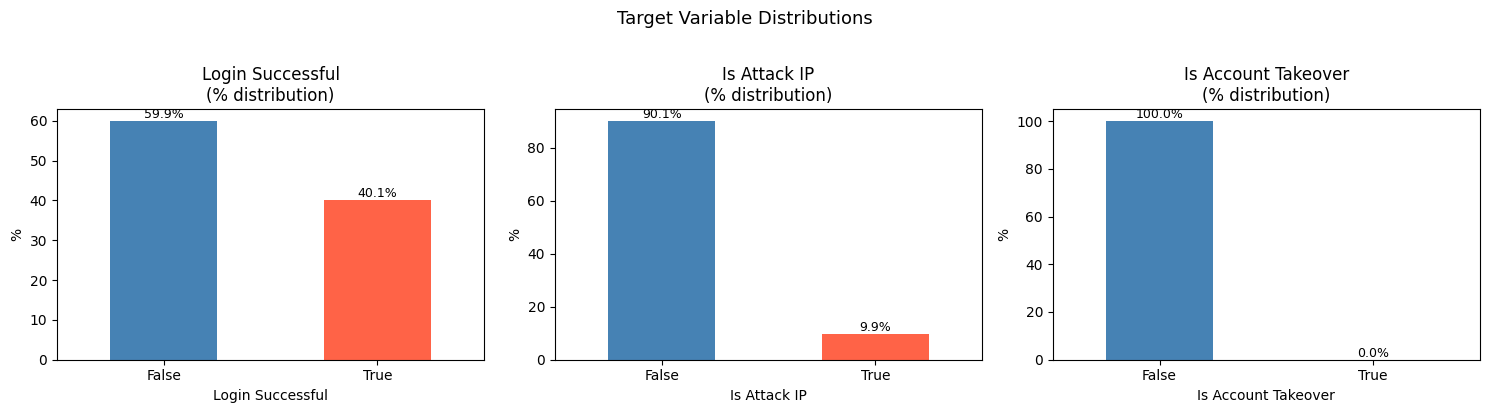

In [8]:
targets = ['Login Successful', 'Is Attack IP', 'Is Account Takeover']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, targets):
    vc = df[col].value_counts(normalize=True).mul(100)
    vc.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
    ax.set_title(f'{col}\n(% distribution)')
    ax.set_ylabel('%')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Target Variable Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Cross-tab: Attack IP vs Account Takeover
ct = pd.crosstab(df['Is Attack IP'], df['Is Account Takeover'],
                 margins=True, margins_name='Total')
print('Is Attack IP  x  Is Account Takeover:')
print(ct)

Is Attack IP  x  Is Account Takeover:
Is Account Takeover   False  True    Total
Is Attack IP                              
False                901257     3   901260
True                  98739     1    98740
Total                999996     4  1000000


In [10]:
# Class balance — counts, percentages, and neg/pos ratio for all three targets
print('=== CLASS BALANCE SUMMARY ===')
for col in ['Login Successful', 'Is Attack IP', 'Is Account Takeover']:
    counts = df[col].value_counts()
    total  = len(df)
    pos    = int(counts.get(True, counts.get(1, 0)))
    neg    = total - pos
    ratio  = neg / pos if pos > 0 else float('inf')
    print(f'\n  {col}')
    print(f'    Total rows   : {total:,}')
    print(f'    Positives    : {pos:,}  ({pos/total*100:.3f}%)')
    print(f'    Negatives    : {neg:,}  ({neg/total*100:.3f}%)')
    print(f'    Neg/Pos ratio: {ratio:.1f}:1')


=== CLASS BALANCE SUMMARY ===

  Login Successful
    Total rows   : 1,000,000
    Positives    : 400,848  (40.085%)
    Negatives    : 599,152  (59.915%)
    Neg/Pos ratio: 1.5:1

  Is Attack IP
    Total rows   : 1,000,000
    Positives    : 98,740  (9.874%)
    Negatives    : 901,260  (90.126%)
    Neg/Pos ratio: 9.1:1

  Is Account Takeover
    Total rows   : 1,000,000
    Positives    : 4  (0.000%)
    Negatives    : 999,996  (100.000%)
    Neg/Pos ratio: 249999.0:1


In [11]:
# Timestamp range + unique counts for key identifiers
print('=== TEMPORAL COVERAGE ===')
ts = pd.to_datetime(df['Login Timestamp'], errors='coerce')
print(f'  Earliest login : {ts.min()}')
print(f'  Latest  login  : {ts.max()}')
print(f'  Span           : {(ts.max() - ts.min()).days} days')

print('\n=== UNIQUE VALUE COUNTS ===')
for col in ['User ID', 'IP Address', 'Country', 'ASN']:
    print(f'  {col:25s}: {df[col].nunique():,}')


=== TEMPORAL COVERAGE ===
  Earliest login : 2020-02-03 12:46:25.828000
  Latest  login  : 2021-02-28 23:57:48.545000
  Span           : 391 days

=== UNIQUE VALUE COUNTS ===
  User ID                  : 460,990
  IP Address               : 431,358
  Country                  : 208
  ASN                      : 4,929


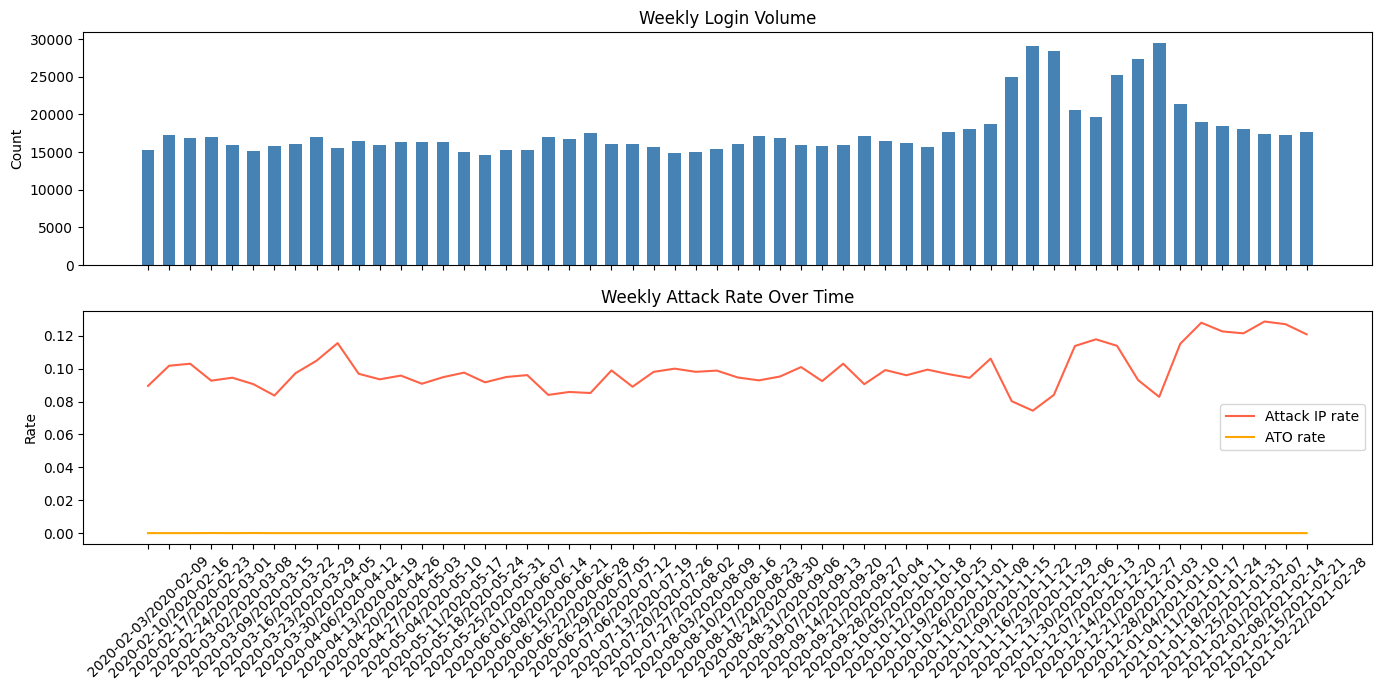

In [12]:
# Attack rate over time — weekly aggregation
df['_ts']   = pd.to_datetime(df['Login Timestamp'], errors='coerce')
df['_week'] = df['_ts'].dt.to_period('W')

weekly = df.groupby('_week').agg(
    total=('Is Attack IP', 'count'),
    attack_ip_rate=('Is Attack IP', 'mean'),
    ato_rate=('Is Account Takeover', 'mean')
).reset_index()
weekly['_week_str'] = weekly['_week'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].bar(weekly['_week_str'], weekly['total'], color='steelblue', width=0.6)
axes[0].set_title('Weekly Login Volume')
axes[0].set_ylabel('Count')

axes[1].plot(weekly['_week_str'], weekly['attack_ip_rate'], label='Attack IP rate',  color='tomato')
axes[1].plot(weekly['_week_str'], weekly['ato_rate'],       label='ATO rate',        color='orange')
axes[1].set_title('Weekly Attack Rate Over Time')
axes[1].set_ylabel('Rate')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
df.drop(columns=['_ts', '_week', '_week_str'], inplace=True, errors='ignore')


## 4. Feature-Level Audit

In [13]:
print('=== NUMERICAL SUMMARY ===')
df.describe().T

=== NUMERICAL SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
index,1000000.0,1.563984e+07,9.027084e+06,1.500000e+02,7.824633e+06,1.562111e+07,2.346641e+07,3.126922e+07
User ID,1000000.0,-1.922546e+18,4.513987e+18,-9.223361e+18,-4.324476e+18,-4.324476e+18,9.206674e+17,9.223309e+18
Round-Trip Time [ms],40563.0,6.723235e+02,1.189353e+03,8.000000e+00,4.710000e+02,5.380000e+02,6.780000e+02,8.658700e+04
ASN,1000000.0,1.622915e+05,1.719289e+05,1.200000e+01,2.969500e+04,4.116400e+04,3.933980e+05,5.077140e+05


In [14]:
# Categorical cardinality
cat_cols = ['Country', 'Region', 'City', 'ASN', 'Browser Name and Version',
            'OS Name and Version', 'Device Type']
card = {col: df[col].nunique() for col in cat_cols}
card_df = pd.Series(card, name='Unique Values').sort_values(ascending=False)
print('=== CATEGORICAL CARDINALITY ===')
print(card_df.to_string())

=== CATEGORICAL CARDINALITY ===
City                        12929
ASN                          4929
Browser Name and Version     1898
Region                       1523
OS Name and Version           366
Country                       208
Device Type                     5


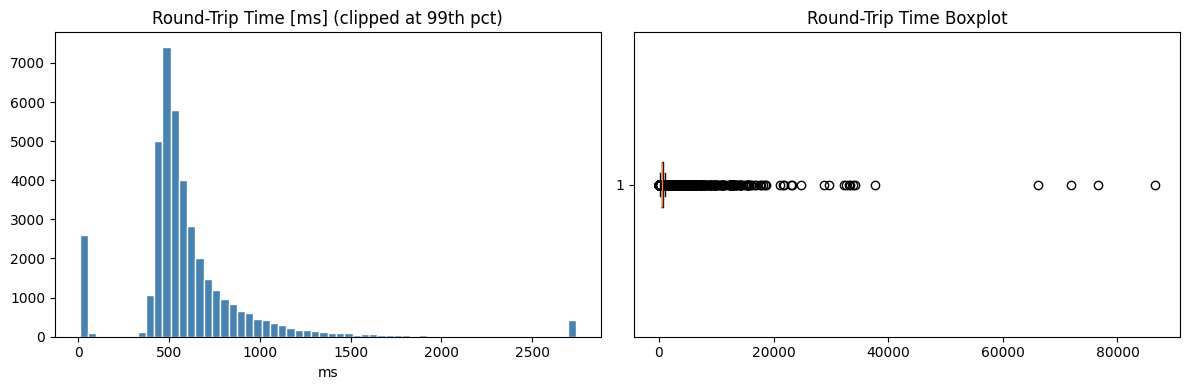

count    40563.000000
mean       672.323521
std       1189.353348
min          8.000000
25%        471.000000
50%        538.000000
75%        678.000000
max      86587.000000
Name: Round-Trip Time [ms], dtype: float64


In [15]:
# Round-Trip Time distribution
rtt = df['Round-Trip Time [ms]'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rtt.clip(upper=rtt.quantile(0.99)), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Round-Trip Time [ms] (clipped at 99th pct)')
axes[0].set_xlabel('ms')
axes[1].boxplot(rtt, vert=False)
axes[1].set_title('Round-Trip Time Boxplot')
plt.tight_layout()
plt.show()
print(rtt.describe())

## 5. Data Cleaning

In [ ]:
df_clean = df.copy()

# 1. Drop the redundant 'index' column if present
if 'index' in df_clean.columns:
    df_clean.drop(columns=['index'], inplace=True)
    print('Dropped column: index')

# 2. Parse Login Timestamp
df_clean['Login Timestamp'] = pd.to_datetime(df_clean['Login Timestamp'], errors='coerce')
print(f'Timestamp NaTs after parse: {df_clean["Login Timestamp"].isna().sum()}')

# 3. Fill missing Round-Trip Time with median
#    Use assignment form — inplace=True is unreliable on column selections in newer pandas
rtt_before = df_clean['Round-Trip Time [ms]'].isna().sum()
rtt_median = df_clean['Round-Trip Time [ms]'].median()
df_clean['Round-Trip Time [ms]'] = df_clean['Round-Trip Time [ms]'].fillna(rtt_median)
rtt_after = df_clean['Round-Trip Time [ms]'].isna().sum()
print(f'RTT: {rtt_before:,} missing → filled with median={rtt_median:.2f}  |  remaining NaN={rtt_after}')

# 4. Fill missing geo/categorical cols with 'Unknown'
geo_cols = ['Country', 'Region', 'City']
for col in geo_cols:
    n_filled = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna('Unknown')
    print(f'{col}: filled {n_filled:,} NaN → "Unknown"')

# 5. Drop duplicate rows
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'\nDuplicate rows removed: {before - len(df_clean):,}')

# 6. Ensure boolean target columns are bool dtype
for col in ['Login Successful', 'Is Attack IP', 'Is Account Takeover']:
    df_clean[col] = df_clean[col].astype(bool)

print(f'\nClean dataset shape: {df_clean.shape}')
df_clean.head(3)


Dropped column: index
Timestamp NaTs after parse: 0
RTT missing filled with median=538.00
Country: filled 0 NaN → "Unknown"
Region: filled 1,549 NaN → "Unknown"
City: filled 264 NaN → "Unknown"

Duplicate rows removed: 0

Clean dataset shape: (1000000, 15)


,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,2020-02-03 12:46:25.828,-4324475583306591935,NaN,37.191.162.246,NO,Oslo County,Oslo,57963,Mozilla/5.0 (Android 6.0.99; Tablet; https://github.com...,Chrome Mobile WebView 85.0.4183,Android 6.0.99,mobile,False,False,False
1,2020-02-03 12:46:52.905,-4324475583306591935,NaN,94.198.241.134,CZ,Hlavni mesto Praha,Prague,62160,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 like Mac OS X...,Chrome Mobile WebView 85.0.4183,iOS 11.2.6,mobile,False,False,False
2,2020-02-03 12:46:55.455,9187119392009558735,NaN,10.0.183.79,RO,Arges,Curtea de Argeş,500372,Mozilla/5.0 (X11; CrOS armv7l 12105.100.0) AppleWebKit/...,Chrome 69.0.3497.17.19,Chrome OS 12105.100.0,desktop,True,False,False


In [17]:
# Verify no missing values remain in critical columns
print('Remaining missing values (key columns):')
key_cols = ['Login Timestamp', 'User ID', 'Round-Trip Time [ms]',
            'IP Address', 'Country', 'Is Attack IP', 'Is Account Takeover']
print(df_clean[key_cols].isnull().sum())

Remaining missing values (key columns):
Login Timestamp              0
User ID                      0
Round-Trip Time [ms]    959437
IP Address                   0
Country                      0
Is Attack IP                 0
Is Account Takeover          0
dtype: int64


## 6. Save Cleaned Data

In [18]:
import os
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

clean_path = os.path.join(OUTPUT_DIR, 'rba_cleaned.parquet')
df_clean.to_parquet(clean_path, index=False, engine='pyarrow')
print(f'Cleaned data saved to: {clean_path}')
print(f'File size: {os.path.getsize(clean_path)/1e6:.1f} MB')


Cleaned data saved to: c:\Users\ruchi\Downloads\rba-dataset.csv\outputs\rba_cleaned.parquet
File size: 47.1 MB


## Summary
| Step | Result |
|------|--------|
| Sample size | 1,000,000 rows |
| Dropped columns | `index` |
| Missing RTT | Filled with median |
| Missing geo | Filled with 'Unknown' |
| Duplicates | Removed |
| Output | `outputs/rba_cleaned.parquet` |

➜ **Next: Notebook 2 — Feature Engineering**